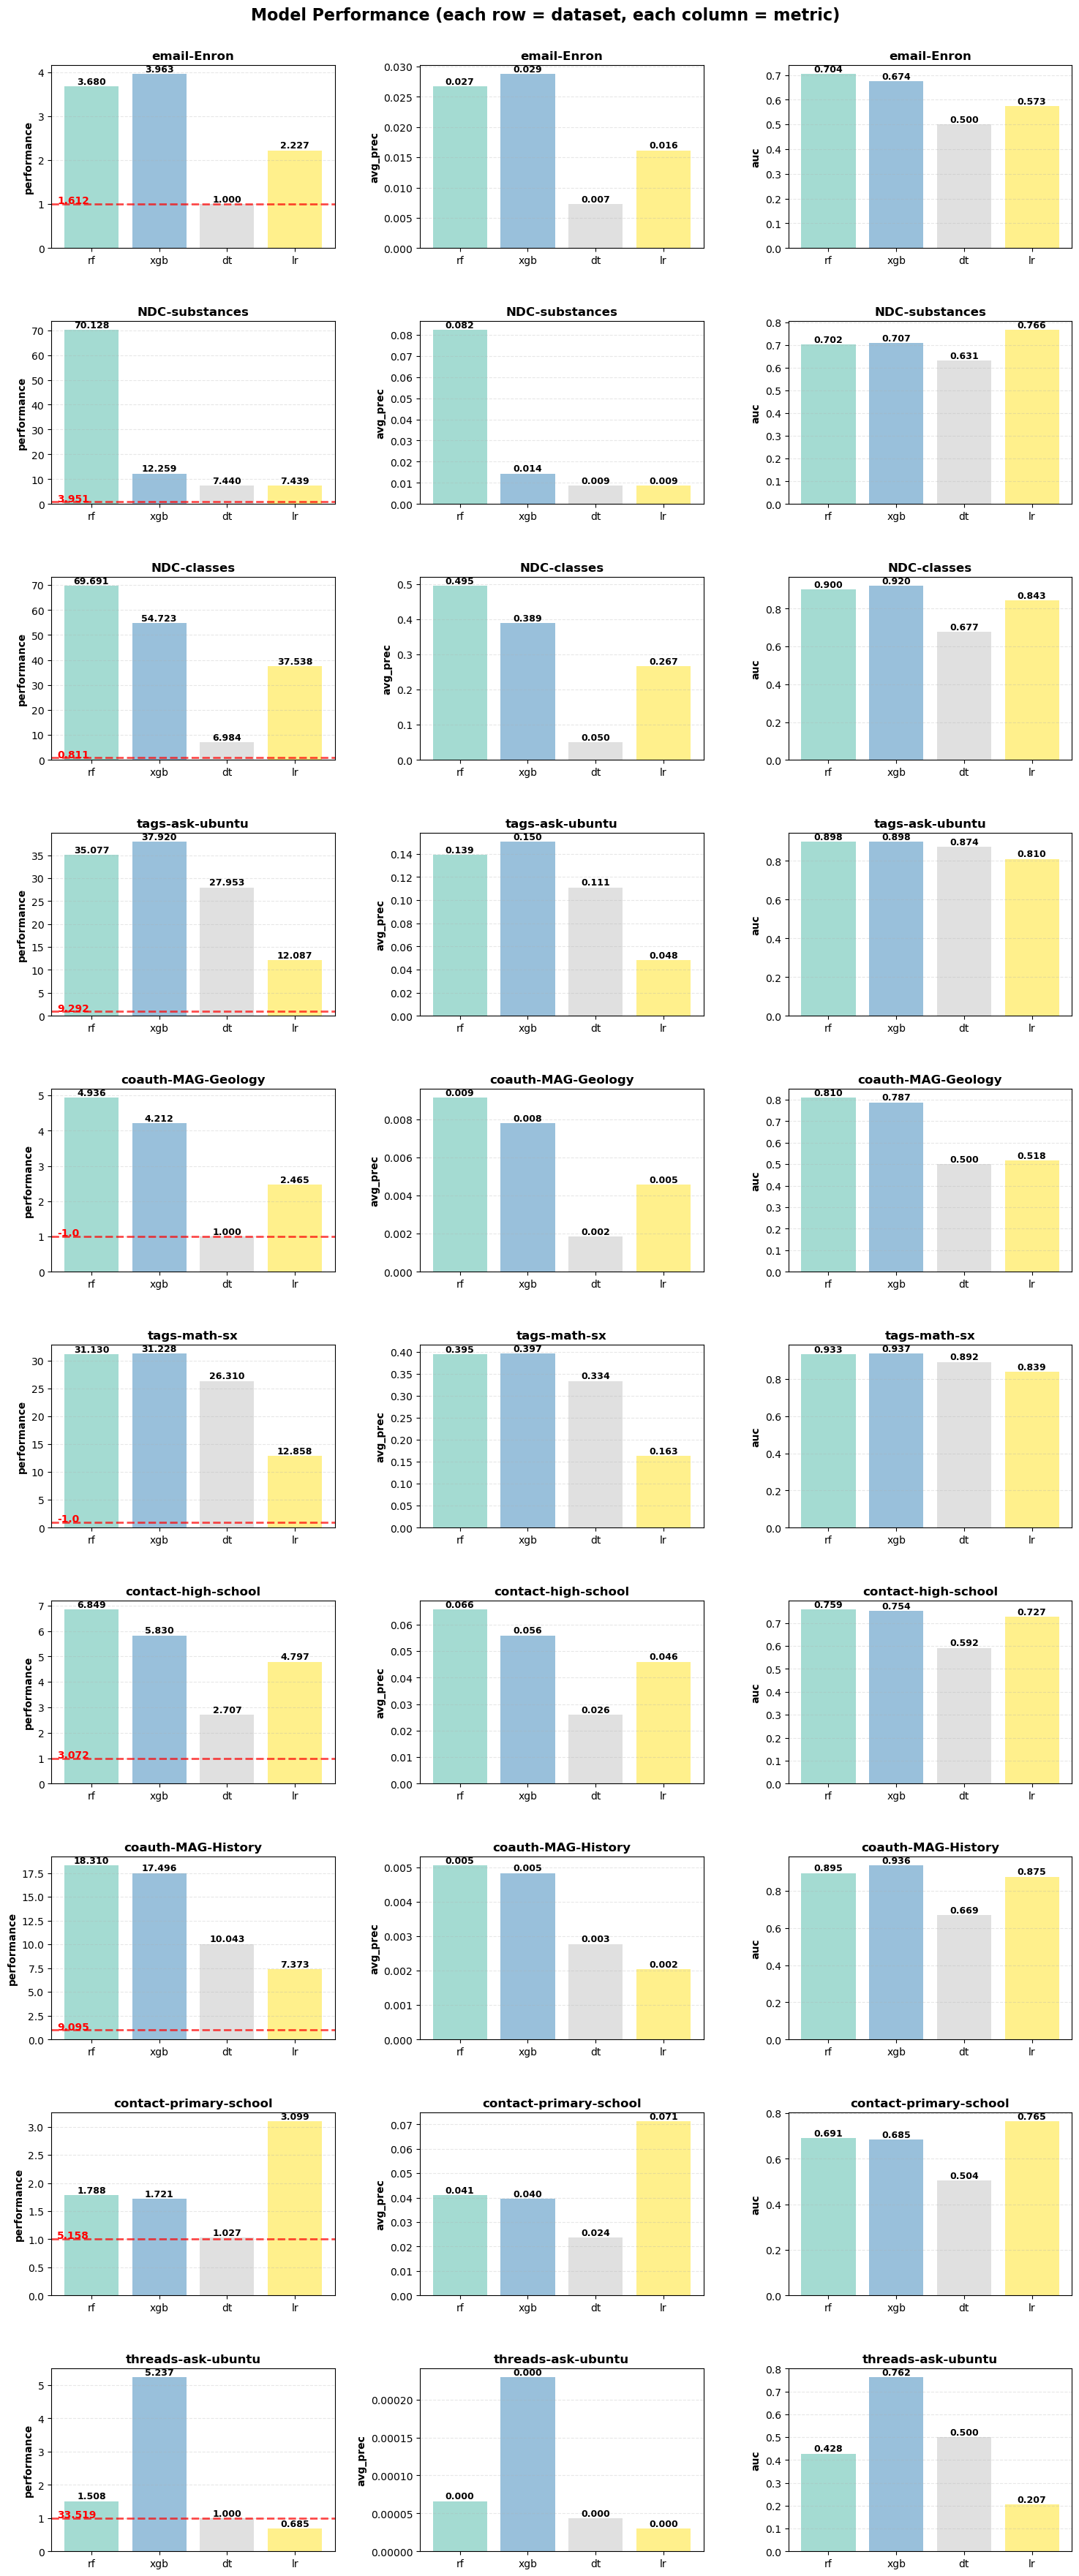

In [76]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


path = 'results'
datasets = [item for item in os.listdir(path) if os.path.isdir(os.path.join(path, item))]
methods = ['rf', 'xgb', 'dt', 'lr']

all_dfs = []
for dataset in datasets:
    for method in methods:
        df = pd.read_csv(f'{path}/{dataset}/metrics/test_{method}.csv')
        df['dataset'] = dataset
        df['method'] = method
        all_dfs.append(df)

combined_df = pd.concat(all_dfs, ignore_index=True)

smpm_baseline = pd.read_csv('data/smpm_baseline.csv')


# Get the metric columns (exclude 'dataset' and 'method')
metrics = ['performance', 'avg_prec', 'auc']

# Get unique datasets
num_datasets = len(datasets)

# Create the figure and subplots - each row is a dataset, each column is a metric
fig, axes = plt.subplots(num_datasets, 3, figsize=(18, 4 * num_datasets))
# fig.suptitle('Model Performance: Each row = Dataset, Each column = Metric', fontsize=16, fontweight='bold')

# Create one subplot for each dataset (rows) and metric (columns)
for row_idx, dataset in enumerate(datasets):
    dataset_data = combined_df[combined_df['dataset'] == dataset]
    
    for col_idx, metric in enumerate(metrics):
        ax = axes[row_idx, col_idx]
        
        # Get values for this metric across all methods
        values = []
        for method in methods:
            method_data = dataset_data[dataset_data['method'] == method]
            values.append(method_data[metric].values[0])
        
        # Create bar plot with different colors for each method
        colors = plt.cm.Set3(np.linspace(0, 1, len(methods)))
        bars = ax.bar(methods, values, alpha=0.8, color=colors)
        
        # Add value labels on top of bars
        for bar, value in zip(bars, values):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2, height,
                   f'{value:.3f}', ha='center', va='bottom', fontsize=9,
                   fontweight='bold')
        
        if col_idx == 0:  # Only for the first column
            ax.axhline(y=1.0, color='red', linestyle='--', linewidth=2, alpha=0.7)
            # Add label for the line
            smpm = smpm_baseline.loc[smpm_baseline.dataset==dataset, 'performance'].iloc[0]
            ax.text(0.02, 1.02, f'{smpm}', transform=ax.get_yaxis_transform(), 
                   color='red', fontsize=10, fontweight='bold')
        
        # # Add grid and set y-limits
        ax.grid(True, alpha=0.3, axis='y', linestyle='--')

        ax.set_title(dataset, fontweight='bold')
        ax.set_ylabel(metric, fontweight='bold')
        
        # Set y-axis limits with some padding for value labels
        # if values:  # Check if values list is not empty
        #     y_max = max(values) * 1.2
        #     ax.set_ylim(0, y_max if y_max > 0 else 1)

plt.suptitle('Model Performance (each row = dataset, each column = metric)', fontsize=16, fontweight='bold')
# plt.tight_layout()
plt.subplots_adjust(top=0.96, hspace=0.4, wspace=0.3)  # Adjust spacing
# plt.savefig('dataset_metric_performance.png', dpi=300, bbox_inches='tight')
plt.show()